In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Dataset de base

In [2]:
df = pd.read_csv('Book_Dataset_1.csv')

print(df.head(10))
print(len(df))

df.describe()

   Unnamed: 0                                              Title  \
0           0                               A Light in the Attic   
1           1                                 Tipping the Velvet   
2           2                                         Soumission   
3           3                                      Sharp Objects   
4           4              Sapiens: A Brief History of Humankind   
5           5                                    The Requiem Red   
6           6  The Dirty Little Secrets of Getting Your Dream...   
7           7  The Coming Woman: A Novel Based on the Life of...   
8           8  The Boys in the Boat: Nine Americans and Their...   
9           9                                    The Black Maria   

             Category  Price  Price_After_Tax  Tax_amount  Avilability  \
0              Poetry  51.77            51.77         0.0           22   
1  Historical Fiction  53.74            53.74         0.0           20   
2             Fiction  50.10 

,Unnamed: 0,Price,Price_After_Tax,Tax_amount,Avilability,Number_of_reviews,Stars
count,1000.000000,1000.00000,1000.00000,1000.0,1000.000000,1000.0,1000.000000
mean,499.500000,35.07035,35.07035,0.0,8.585000,0.0,2.923000
std,288.819436,14.44669,14.44669,0.0,5.654622,0.0,1.434967
min,0.000000,10.00000,10.00000,0.0,1.000000,0.0,1.000000
25%,249.750000,22.10750,22.10750,0.0,3.000000,0.0,2.000000
50%,499.500000,35.98000,35.98000,0.0,7.000000,0.0,3.000000
75%,749.250000,47.45750,47.45750,0.0,14.000000,0.0,4.000000
max,999.000000,59.99000,59.99000,0.0,22.000000,0.0,5.000000


In [3]:
genre_total = df['Category'].value_counts()
unique_categories = df['Category'].nunique()
for category, count in genre_total.items():
    print(f"Category: {category}, Count: {count}")
print(f"Unique categories: {unique_categories}")

Category: Default, Count: 152
Category: Nonfiction, Count: 110
Category: Sequential Art, Count: 75
Category: Add a comment, Count: 67
Category: Fiction, Count: 65
Category: Young Adult, Count: 54
Category: Fantasy, Count: 48
Category: Romance, Count: 35
Category: Mystery, Count: 32
Category: Food and Drink, Count: 30
Category: Childrens, Count: 29
Category: Historical Fiction, Count: 26
Category: Poetry, Count: 19
Category: Classics, Count: 19
Category: History, Count: 18
Category: Horror, Count: 17
Category: Womens Fiction, Count: 17
Category: Science Fiction, Count: 16
Category: Science, Count: 14
Category: Music, Count: 13
Category: Business, Count: 12
Category: Travel, Count: 11
Category: Philosophy, Count: 11
Category: Thriller, Count: 11
Category: Humor, Count: 10
Category: Autobiography, Count: 9
Category: Art, Count: 8
Category: Psychology, Count: 7
Category: Religion, Count: 7
Category: Spirituality, Count: 6
Category: Christian Fiction, Count: 6
Category: New Adult, Count: 6


Le dataser de base ne contient pas assez des données pour entraîner un modèle de génération de texte. Il est donc nécessaire d'utiliser un dataset plus grand et plus riche en informations.

# Option Dataset n2

In [4]:
df2 = pd.read_csv('BooksDataset.csv')

df2.head(10)

,Title,Authors,Description,Category,Publisher,Publish Date,Price
0,Goat Brothers,"By Colton, Larry",NaN,"History , General",Doubleday,"Friday, January 1, 1993",Price Starting at $8.79
1,The Missing Person,"By Grumbach, Doris",NaN,"Fiction , General",Putnam Pub Group,"Sunday, March 1, 1981",Price Starting at $4.99
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",NaN,"Cooking , Reference",Workman Pub Co,"Thursday, September 1, 1983",Price Starting at $4.99
3,When Your Corporate Umbrella Begins to Leak: A...,"By Davis, Paul D.",NaN,NaN,Natl Pr Books,"Monday, April 1, 1991",Price Starting at $4.99
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",NaN,NaN,Amy Spangler,"Saturday, February 1, 1997",Price Starting at $5.32
5,The Foundation of Leadership: Enduring Princip...,"By Short, Bo",NaN,NaN,Excalibur Press,"Wednesday, January 1, 1997",Price Starting at $6.06
6,Chicken Soup for the Soul: 101 Stories to Open...,"By Canfield, Jack (COM) and Hansen, Mark Victo...",NaN,"Self-help , Personal Growth , Self-Esteem",Health Communications Inc,"Saturday, May 1, 1993",Price Starting at $4.99
7,Journey Through Heartsongs,"By Stepanek, Mattie J. T.",Collects poems written by the eleven-year-old ...,"Poetry , General",VSP Books,"Saturday, September 1, 2001",Price Starting at $19.96
8,In Search of Melancholy Baby,"By Aksyonov, Vassily, Heim, Michael Henry, and...",The Russian author offers an affectionate chro...,"Biography & Autobiography , General",Random House,"Monday, June 1, 1987",Price Starting at $4.99
9,Christmas Cookies,"By Eakin, Katherine M. and Deaman, Joane (EDT)",NaN,"Cooking , General",Oxmoor House,"Sunday, June 1, 1986",Price Starting at $12.98


In [5]:
print(len(df2))
df2.describe()

103082


,Title,Authors,Description,Category,Publisher,Publish Date,Price
count,103082,103082,70213,76912,103074,103082,103082
unique,97818,63580,68831,3106,13029,956,1387
top,The Nutcracker,By,For Ingest Only - Data needs to be cleaned up ...,"Fiction , General",Simon & Schuster,"Thursday, January 1, 2004",Price Starting at $5.29
freq,12,1043,30,2549,1521,868,41876


In [6]:
genres_unique = df2['Category'].nunique()
gneres_total = df2['Category'].value_counts()
print(f"Unique categories: {genres_unique}")

for category, count in df2['Category'].value_counts().items():
    print(f"Category: {category}, Count: {count}")

Unique categories: 3106
Category:  Fiction , General, Count: 2549
Category:  Fiction , Literary, Count: 1709
Category:  Fiction , Mystery & Detective , General, Count: 1690
Category:  Fiction , Thrillers , General, Count: 1115
Category:  Fiction , Romance , Contemporary, Count: 1074
Category:  Fiction , Thrillers , Suspense, Count: 1069
Category:  Religion , General, Count: 918
Category:  Cooking , General, Count: 840
Category:  Fiction , Romance , Historical , General, Count: 738
Category:  Fiction , Romance , General, Count: 696
Category:  Fiction , Science Fiction , General, Count: 678
Category:  History , General, Count: 624
Category:  Juvenile Fiction , General, Count: 589
Category:  Social Science , General, Count: 584
Category:  Business & Economics , General, Count: 583
Category:  Juvenile Nonfiction , General, Count: 559
Category:  Family & Relationships , Parenting , General, Count: 531
Category:  Religion , Christian Life , General, Count: 525
Category:  Humor , General, Cou

In [7]:
#drop the category name after the first comma
df2['Category'] = df2['Category'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)
for category, count in df2['Category'].value_counts().items():
    print(f"Category: {category}, Count: {count}")
genres_unique = df2['Category'].nunique()

print(f"Unique categories after cleaning: {genres_unique}")

Category:  Fiction , Count: 18769
Category:  Juvenile Fiction , Count: 6752
Category:  Religion , Count: 5178
Category:  Cooking , Count: 3930
Category:  Juvenile Nonfiction , Count: 3105
Category:  Business & Economics , Count: 3073
Category:  History , Count: 2444
Category:  Biography & Autobiography , Count: 2288
Category:  Political Science , Count: 2028
Category:  Health & Fitness , Count: 1833
Category:  Social Science , Count: 1763
Category:  Travel , Count: 1704
Category:  Young Adult Fiction , Count: 1585
Category:  Family & Relationships , Count: 1509
Category:  Sports & Recreation , Count: 1280
Category:  Self-help , Count: 1277
Category:  Humor , Count: 1104
Category:  Reference , Count: 1034
Category:  Science , Count: 1026
Category:  Crafts & Hobbies , Count: 1011
Category:  House & Home , Count: 1008
Category:  Computers , Count: 992
Category:  Psychology , Count: 986
Category:  Medical , Count: 805
Category:  Pets , Count: 777
Category:  Gardening , Count: 769
Category:

In [8]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103082 entries, 0 to 103081
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Title         103082 non-null  object
 1   Authors       103082 non-null  object
 2   Description   70213 non-null   object
 3   Category      76912 non-null   object
 4   Publisher     103074 non-null  object
 5   Publish Date  103082 non-null  object
 6   Price         103082 non-null  object
dtypes: object(7)
memory usage: 5.5+ MB


In [9]:
df2.isna().sum()

Title               0
Authors             0
Description     32869
Category        26170
Publisher           8
Publish Date        0
Price               0
dtype: int64

In [10]:
df2['Description'].dropna(inplace=True)
df_clean = df2.dropna(subset=['Description'])
df_clean.isna().sum()

Title              0
Authors            0
Description        0
Category        4908
Publisher          0
Publish Date       0
Price              0
dtype: int64

In [11]:
#change the cat empty values to generic category
df_clean['Category'] = df_clean['Category'].fillna('Unknown')
df_clean.isna().sum()

C:\Users\Héctor\AppData\Local\Temp\ipykernel_800\3127525647.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Category'] = df_clean['Category'].fillna('Unknown')


Title           0
Authors         0
Description     0
Category        0
Publisher       0
Publish Date    0
Price           0
dtype: int64

In [12]:
#check doubles in the dataset
df_clean.duplicated().sum()

df_clean.drop_duplicates(inplace=True)

C:\Users\Héctor\AppData\Local\Temp\ipykernel_800\3283903636.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop_duplicates(inplace=True)


In [13]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70206 entries, 7 to 103081
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         70206 non-null  object
 1   Authors       70206 non-null  object
 2   Description   70206 non-null  object
 3   Category      70206 non-null  object
 4   Publisher     70206 non-null  object
 5   Publish Date  70206 non-null  object
 6   Price         70206 non-null  object
dtypes: object(7)
memory usage: 4.3+ MB


Ce dataset contient plus de 100 000 livres avec des informations détaillées sur chaque livre, y compris le titre, l'auteur, la description, la catégorie et d'autres métadonnées. Il est plus approprié pour entraîner un modèle de génération de texte. Après avoir nettoyé et supprimé les ouvres sans description qui est necessaire à le projet, aussi comme les peu de doublons, le dataset a été réduit à 70 000 livres.

# Option Dataset déjà nettoyé

In [14]:
df3 = pd.read_csv('BooksDatasetClean.csv')

df3.head(10)

,Title,Authors,Description,Category,Publisher,Price Starting With ($),Publish Date (Month),Publish Date (Year)
0,Goat Brothers,"By Colton, Larry",NaN,"History , General",Doubleday,8.79,January,1993
1,The Missing Person,"By Grumbach, Doris",NaN,"Fiction , General",Putnam Pub Group,4.99,March,1981
2,Don't Eat Your Heart Out Cookbook,"By Piscatella, Joseph C.",NaN,"Cooking , Reference",Workman Pub Co,4.99,September,1983
3,When Your Corporate Umbrella Begins to Leak: A...,"By Davis, Paul D.",NaN,NaN,Natl Pr Books,4.99,April,1991
4,Amy Spangler's Breastfeeding : A Parent's Guide,"By Spangler, Amy",NaN,NaN,Amy Spangler,5.32,February,1997
5,The Foundation of Leadership: Enduring Princip...,"By Short, Bo",NaN,NaN,Excalibur Press,6.06,January,1997
6,Chicken Soup for the Soul: 101 Stories to Open...,"By Canfield, Jack (COM) and Hansen, Mark Victo...",NaN,"Self-help , Personal Growth , Self-Esteem",Health Communications Inc,4.99,May,1993
7,Journey Through Heartsongs,"By Stepanek, Mattie J. T.",Collects poems written by the eleven-year-old ...,"Poetry , General",VSP Books,19.96,September,2001
8,In Search of Melancholy Baby,"By Aksyonov, Vassily, Heim, Michael Henry, and...",The Russian author offers an affectionate chro...,"Biography & Autobiography , General",Random House,4.99,June,1987
9,Christmas Cookies,"By Eakin, Katherine M. and Deaman, Joane (EDT)",NaN,"Cooking , General",Oxmoor House,12.98,June,1986


In [15]:
print(len(df3))
df3.describe()

103063


,Price Starting With ($),Publish Date (Year)
count,103063.000000,103063.000000
mean,6.777172,1994.522865
std,8.932151,13.193129
min,4.890000,1755.000000
25%,4.990000,1989.000000
50%,5.290000,1997.000000
75%,5.700000,2003.000000
max,1095.000000,2023.000000


La difference avec le dataset pas nettoyé n'est pas trés grande, je garde donc le dataset nettoyé pour le projet. Il est plus approprié pour entraîner un modèle de génération de texte.

# Option Dataset n3 : Best_Books_Ever.csv

`BooksDatasetClean.csv` seul pose un problème de diversité : c'est un catalogue éditeur (titre, auteur, description, catégorie, prix, date) sans série, langue, nombre de pages ni note de lecteurs. `Best_Books_Ever.csv` (export Goodreads) apporte ces dimensions manquantes et un autre angle de couverture (best-sellers, jeunesse, genres de niche).

In [16]:
df4 = pd.read_csv('Best_Books_Ever.csv')

print(len(df4))
df4[['title', 'series', 'author', 'rating', 'language', 'genres', 'pages', 'publishDate']].head(10)

52478


,title,series,author,rating,language,genres,pages,publishDate
0,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,English,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...",374,09/14/08
1,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,English,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",870,09/28/04
2,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,English,"['Classics', 'Fiction', 'Historical Fiction', ...",324,05/23/06
3,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,English,"['Classics', 'Fiction', 'Romance', 'Historical...",279,10/10/00
4,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,English,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...",501,09/06/06
5,The Book Thief,NaN,Markus Zusak (Goodreads Author),4.37,English,"['Historical Fiction', 'Fiction', 'Young Adult...",552,03/14/06
6,Animal Farm,NaN,"George Orwell, Russell Baker (Preface), C.M. W...",3.95,English,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",141,04/28/96
7,The Chronicles of Narnia,The Chronicles of Narnia (Publication Order) #1–7,"C.S. Lewis, Pauline Baynes (Illustrator)",4.26,English,"['Fantasy', 'Classics', 'Fiction', 'Young Adul...",767,09/16/02
8,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,The Lord of the Rings #0-3,J.R.R. Tolkien,4.60,English,"['Fantasy', 'Fiction', 'Classics', 'Adventure'...",1728,09/25/12
9,Gone with the Wind,NaN,Margaret Mitchell,4.30,English,"['Classics', 'Historical Fiction', 'Fiction', ...",1037,04/01/99


In [17]:
df4.isna().sum()

bookId                  0
title                   0
series              29008
author                  0
rating                  0
description          1338
language             3806
isbn                    0
genres                  0
characters              0
bookFormat           1473
edition             47523
pages                2347
publisher            3696
publishDate           880
firstPublishDate    21326
awards                  0
numRatings              0
ratingsByStars          0
likedPercent          622
setting                 0
coverImg              605
bbeScore                0
bbeVotes                0
price               14365
dtype: int64

In [18]:
import ast

# Le champ 'genres' est une liste Python sous forme de texte : "['Young Adult', 'Fiction', ...]"
primary_genre = df4['genres'].apply(
    lambda x: ast.literal_eval(x)[0] if isinstance(x, str) and x.startswith('[') and ast.literal_eval(x) else None
)
print(f"Genres principaux uniques : {primary_genre.nunique()}")
print(primary_genre.value_counts().head(20))

print("\nLangues principales :")
print(df4['language'].value_counts().head(10))

Genres principaux uniques : 401
genres
Fiction               6141
Fantasy               5556
Romance               3338
Young Adult           3145
Nonfiction            2564
Historical Fiction    2228
Mystery               1943
Science Fiction       1426
Classics              1140
History               1016
Poetry                 944
Horror                 885
Paranormal             784
Manga                  658
Childrens              630
Philosophy             595
Thriller               584
Comics                 533
Urban Fantasy          524
Short Stories          477
Name: count, dtype: int64

Langues principales :
language
English       42661
Arabic         1038
Spanish         687
French          579
German          528
Indonesian      371
Portuguese      363
Italian         255
Dutch           215
Turkish         211
Name: count, dtype: int64


`Best_Books_Ever.csv` couvre des genres peu ou pas représentés dans `BooksDatasetClean.csv` (Dystopia, Paranormal Romance, Urban Fantasy, Manga...) et fournit série/langue/pages/note pour la quasi-totalité des livres. Il complète bien la diversité du référentiel, au prix d'un certain recoupement avec les classiques déjà présents dans les deux autres sources (Pride and Prejudice, 1984, etc.) — géré par la fusion + dédoublonnage ci-dessous.

# Fusion des trois datasets

Pour maximiser la diversité du référentiel (catalogue éditeur généraliste + catalogue Goodreads orienté lecteurs), les trois sources sont fusionnées dans un schéma commun minimal : **titre, auteur, description, année**, complété par **série, langue, pages, note** quand disponibles (`Book_Dataset_1` n'a ni auteur ni année ; `BooksDatasetClean` n'a ni série, ni langue, ni pages, ni note). La fusion est implémentée dans `data_cleaning.merge_datasets()` pour rester la même que celle utilisée par l'application (pas de logique dupliquée entre ce notebook et `app.py`).

In [19]:
from data_cleaning import merge_datasets, deduplicate_books, load_and_clean_dataset, get_statistics

merged = merge_datasets()
merged['source'].value_counts()

[OK] Fusion : 156541 livres (103063 books_dataset_clean, 52478 best_books_ever, 1000 book_dataset_1)


source
books_dataset_clean    103063
best_books_ever         52478
book_dataset_1           1000
Name: count, dtype: int64

## Dédoublonnage prudent (titre + auteur)

Un même livre peut apparaître dans plusieurs sources avec des descriptions différentes (résumé éditeur vs résumé Goodreads) — on ne peut donc pas dédoublonner sur le contenu de la description, seulement sur l'identité titre+auteur. Mais un même titre peut aussi correspondre à deux livres réellement différents écrits par des auteurs différents : dans ce cas il ne faut **pas** fusionner.

`deduplicate_books()` applique donc la règle suivante : pour un même titre, si tous les auteurs connus concordent (ou si l'un des deux est manquant, cas de `Book_Dataset_1`), les lignes sont fusionnées en une seule — la description la plus complète est gardée, et les champs manquants (année, série, langue, pages, note) sont complétés depuis les autres sources. Si plusieurs auteurs différents partagent le même titre, les livres restent distincts.

In [20]:
deduped = deduplicate_books(merged)

# Exemple de fusion inter-source : "The Hunger Games" référencé par plusieurs sources
deduped[deduped['title'].str.contains('Hunger Games', case=False, na=False)][
    ['title', 'authors', 'source', 'year', 'series', 'language', 'pages', 'rating']
].head(5)

[OK] Doublons fusionnés : 3432 livres (156541 -> 153109)


,title,authors,source,year,series,language,pages,rating
764,The Hunger Games (The Hunger Games #1),NaN,book_dataset_1,NaN,NaN,NaN,NaN,5.00
784,Mockingjay (The Hunger Games #3),NaN,book_dataset_1,NaN,NaN,NaN,NaN,4.00
106780,The Hunger Games,Suzanne Collins,best_books_ever,NaN,The Hunger Games #1,English,374.0,4.33
106881,The Hunger Games Trilogy Boxset,"Suzanne Collins, Guillaume Fournier (Translato...",best_books_ever,NaN,The Hunger Games #1-3,English,1155.0,4.48
110757,The Hunger Games: Official Illustrated Movie C...,Kate Egan,best_books_ever,2012.0,The Hunger Games Companions,English,160.0,4.52


## Pipeline finale (fusion + dédoublonnage + nettoyage + regroupement de genres)

`load_and_clean_dataset()` enchaîne désormais : fusion des 3 sources, dédoublonnage, suppression des lignes sans titre/description, nettoyage du texte, regroupement des genres bruts (taxonomies multi-niveaux + listes de genres Goodreads) en un petit nombre de genres macro, bucketing de la période, extraction de mots-clés TF-IDF. Le résultat est mis en cache (`cleaned_books_cache.pkl`) car cette pipeline est coûteuse (~2 min, dominé par le TF-IDF sur >150k descriptions).

In [21]:
df_final = load_and_clean_dataset()
get_statistics(df_final)

[OK] Chargement du dataset nettoyé depuis le cache (cleaned_books_cache.pkl)...


{'total_books': 119671,
 'sources': {'books_dataset_clean': 67869,
  'best_books_ever': 50827,
  'book_dataset_1': 975},
 'unique_genres': 15,
 'top_genres': {'fiction': 27347,
  'young_adult': 15263,
  'lifestyle': 12503,
  'science_academic': 12484,
  'unknown': 8738,
  'fantasy_scifi': 8412,
  'other': 7924,
  'history_biography': 5596,
  'spirituality_philosophy': 5360,
  'romance': 4920,
  'arts_poetry': 3995,
  'mystery_thriller': 2853,
  'sequential_art': 1817,
  'horror': 1292,
  'humor': 1167},
 'missing_authors': np.int64(744),
 'missing_year': np.int64(2833),
 'average_description_length_words': np.float64(129.89183678585457),
 'period_distribution': {'1900s': 36,
  '1910s': 21,
  '1920s': 42,
  '1930s': 76,
  '1940s': 94,
  '1950s': 262,
  '1960s': 656,
  '1970s': 2302,
  '1980s': 10259,
  '1990s': 30444,
  '2000s': 47453,
  '2010s': 24597,
  '2020s': 449,
  '2030s': 1,
  'Avant 1900': 146,
  'Inconnue': 2833},
 'language_distribution': {'English': 42105,
  'Arabic': 947,
 

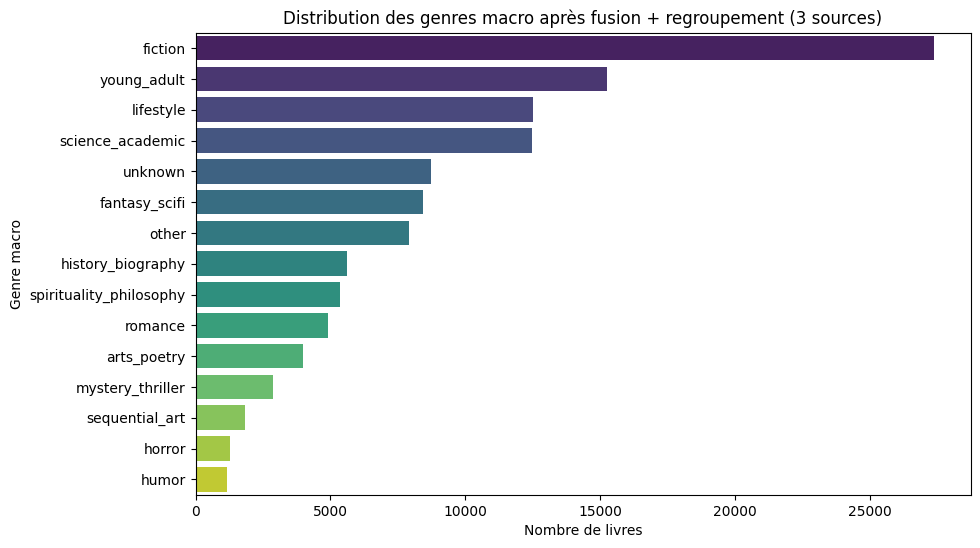

Genres macro : 15


In [22]:
genre_counts = df_final['genre_clean'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette='viridis', legend=False)
plt.title("Distribution des genres macro après fusion + regroupement (3 sources)")
plt.xlabel("Nombre de livres")
plt.ylabel("Genre macro")
plt.show()

print(f"Genres macro : {df_final['genre_clean'].nunique()}")

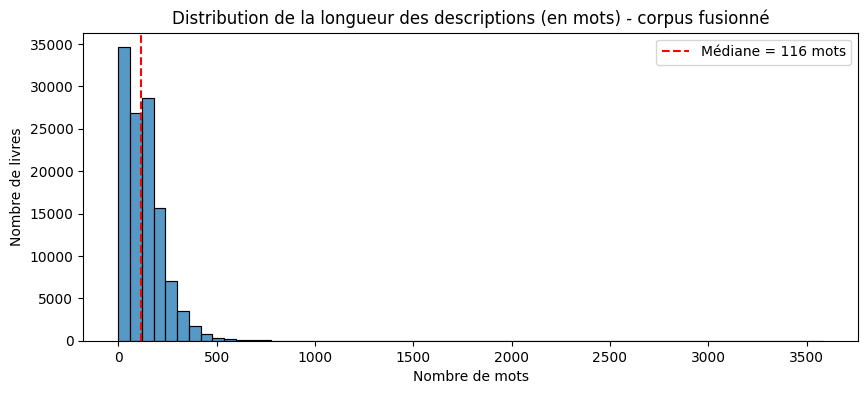

count    119671.000000
mean        129.891837
std         100.586553
min           0.000000
25%          49.000000
50%         116.000000
75%         178.000000
max        3583.000000
Name: desc_clean, dtype: float64


In [23]:
desc_word_counts = df_final['desc_clean'].str.split().apply(len)

plt.figure(figsize=(10, 4))
sns.histplot(desc_word_counts, bins=60)
plt.axvline(desc_word_counts.median(), color='red', linestyle='--', label=f"Médiane = {desc_word_counts.median():.0f} mots")
plt.title("Distribution de la longueur des descriptions (en mots) - corpus fusionné")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de livres")
plt.legend()
plt.show()

print(desc_word_counts.describe())

In [24]:
df_final[['title', 'authors_clean', 'genre_clean', 'year', 'series', 'language', 'pages', 'rating', 'keywords', 'source']].sample(8, random_state=42)

,title,authors_clean,genre_clean,year,series,language,pages,rating,keywords,source
40240,The Guardian (The O'Malley Series #2),"Henderson, Dee",fiction,2001.0,NaN,NaN,NaN,NaN,"marcus, going, investigative, judge, assignment",books_dataset_clean
89908,The Eden Express: A Memoir of Insanity,"Mark Vonnegut , Kurt Vonnegut Jr.",other,2002.0,NaN,English,304.0,3.87,"eden, express, humor, let, experience",best_books_ever
18553,"The South Beach Diet: The Delicious, Doctor-De...","Agatston, Arthur, M.D.",lifestyle,2005.0,NaN,NaN,NaN,NaN,"foods, diet, right, fat, normal",books_dataset_clean
1025,Dark Places,,other,NaN,NaN,NaN,NaN,5.00,"ben, club, secret, killer, obsessed",book_dataset_1
83638,Moonraker's Bride,Madeleine Brent,romance,1973.0,NaN,English,352.0,4.31,"lucy, china, die, finds, grim",best_books_ever
110769,Jejak Kupu-kupu,Agnes Jessica,romance,2005.0,NaN,Indonesian,520.0,3.86,"yang, dia, tidak, itu, dan",best_books_ever
64465,The Creativity Book: A Year's Worth of Inspira...,"Maisel, Eric",spirituality_philosophy,2000.0,NaN,NaN,NaN,NaN,"creativity, paint, encourages, foremost, guided",books_dataset_clean
53477,CAPTIVE HEART,"Conn, Phoebe",unknown,1985.0,NaN,NaN,NaN,NaN,"mistress, slave, task, fierce, warrior",books_dataset_clean


## Conclusion

La fusion des trois sources porte le référentiel de 67 508 (BooksDatasetClean seul) à un corpus bien plus diversifié combinant catalogue éditeur généraliste et catalogue Goodreads (séries, langues, pages, notes lecteurs), avec un nombre de genres macro réduit à une quinzaine (`genre_clean`) au lieu des 3106 catégories brutes / 440 genres bruts cumulés des trois sources.

`app.py` et `book_recommendation_system.py` ont été mis à jour pour utiliser `data_cleaning.load_and_clean_dataset()` (suppression de la logique de nettoyage dupliquée), afficher les nouveaux champs (auteur, année, série, langue, pages, note) à la place du prix, et calculer la similarité de façon vectorisée plutôt que par boucle Python — indispensable vu la taille du corpus, désormais piloté par `cleaned_books_cache.pkl` (dataset nettoyé) et `embeddings_books.pkl` (embeddings SBERT), tous deux régénérés automatiquement si absents.